# Laboratorio 4 — Análisis de Datos GeoEspaciales
## Cianobacteria en los lagos de Atitlán y Amatitlán con Sentinel-2

Universidad del Valle de Guatemala — CC3084 Data Science — Semestre II 2026

In [6]:
#!pip install openeo rasterio numpy pandas matplotlib

In [30]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import openeo
import folium

# Las divisiones de los índices generan 0/0 en píxeles sin dato; se manejan como NaN.
np.seterr(divide="ignore", invalid="ignore")

DATOS = Path("data")
(DATOS / "raw").mkdir(parents=True, exist_ok=True)
(DATOS / "resultados").mkdir(parents=True, exist_ok=True)


---
## 1. Conexión al API de Sentinel-2

Usamos el módulo `openeo` contra el backend del *Copernicus Data Space Ecosystem*.
`authenticate_oidc()` hay que abrir el navegador para iniciar sesión con nuestro usuario de Copernicus Browser y el token queda guardado para las siguientes ejecuciones.

In [8]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()
connection

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

---
## 2. Áreas de interés y fechas

11 fechas por lago, elegidas por su baja nubosidad. 

In [9]:
lago_atitlan = {
    "west": -91.326256,
    "east": -91.07151,
    "south": 14.5948,
    "north": 14.750979,
}
lago_amatitlan = {
    "west": -90.638065,
    "east": -90.512924,
    "south": 14.412347,
    "north": 14.493799,
}

LAGOS = {"Atitlan": lago_atitlan, "Amatitlan": lago_amatitlan}

In [10]:
# Fechas oficiales del laboratorio con su nubosidad reportada.
ESCENAS = pd.DataFrame(
    [
        ("Atitlan",   "2025-01-18",  0.02, "Sentinel-2B"),
        ("Atitlan",   "2025-04-13",  0.54, "Sentinel-2C"),
        ("Atitlan",   "2025-05-13",  4.37, "Sentinel-2C"),
        ("Atitlan",   "2025-07-17",  3.57, "Sentinel-2A"),
        ("Atitlan",   "2025-11-21",  3.15, "Sentinel-2A"),
        ("Atitlan",   "2025-12-29",  3.17, "Sentinel-2C"),
        ("Atitlan",   "2026-02-12",  0.04, "Sentinel-2B"),
        ("Atitlan",   "2026-03-24",  3.17, "Sentinel-2B"),
        ("Atitlan",   "2026-04-13",  0.01, "Sentinel-2B"),
        ("Atitlan",   "2026-04-28",  4.96, "Sentinel-2C"),
        ("Atitlan",   "2026-07-22",  4.02, "Sentinel-2B"),
        ("Amatitlan", "2025-01-28",  0.06, "Sentinel-2B"),
        ("Amatitlan", "2025-04-15",  0.09, "Sentinel-2A"),
        ("Amatitlan", "2025-04-28",  1.03, "Sentinel-2B"),
        ("Amatitlan", "2025-11-24",  0.50, "Sentinel-2B"),
        ("Amatitlan", "2026-01-08",  0.77, "Sentinel-2C"),
        ("Amatitlan", "2026-02-02",  0.39, "Sentinel-2B"),
        ("Amatitlan", "2026-02-07",  0.02, "Sentinel-2C"),  # cobertura parcial (~57%)
        ("Amatitlan", "2026-03-29",  0.01, "Sentinel-2C"),
        ("Amatitlan", "2026-04-13",  0.09, "Sentinel-2B"),
        ("Amatitlan", "2026-04-28",  4.96, "Sentinel-2C"),
        ("Amatitlan", "2026-06-19", 13.00, "Sentinel-2A"),
    ],
    columns=["lago", "fecha", "nubosidad", "satelite"],
)

ESCENAS

,lago,fecha,nubosidad,satelite
0,Atitlan,2025-01-18,0.02,Sentinel-2B
1,Atitlan,2025-04-13,0.54,Sentinel-2C
2,Atitlan,2025-05-13,4.37,Sentinel-2C
3,Atitlan,2025-07-17,3.57,Sentinel-2A
4,Atitlan,2025-11-21,3.15,Sentinel-2A
5,Atitlan,2025-12-29,3.17,Sentinel-2C
6,Atitlan,2026-02-12,0.04,Sentinel-2B
7,Atitlan,2026-03-24,3.17,Sentinel-2B
8,Atitlan,2026-04-13,0.01,Sentinel-2B
9,Atitlan,2026-04-28,4.96,Sentinel-2C


---
### 2.1 Descarga de los datos raster

Solo descargamos las 9 bandas que necesitan los tres índices, remuestreadas a
**20 m** (la resolución nativa de B05, B07, B8A, B11 y B12). Así evitamos bajar
escenas completas.

| Índice | Bandas |
|---|---|
| NDVI | B04, B08 |
| NDWI | B03, B08 |
| Cianobacteria (NDCI + máscara de agua) | B02, B03, B04, B05, B07, B08, B8A, B11, B12 |

Usamos el producto **L2A** (reflectancia de superficie, ya corregida
atmosféricamente), que es el mismo que usa el cuaderno de ejemplo del curso.

In [11]:
BANDAS = ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"]


def descargar_escena(lago, fecha):
    """Descarga las bandas de un lago en una fecha. Si el archivo ya existe, no repite la descarga."""
    ruta = DATOS / "raw" / f"{lago}_{fecha}.tif"
    if ruta.exists():
        return ruta

    # openEO pide un intervalo; usamos [fecha, fecha+1] para traer solo ese día.
    dia_siguiente = (pd.Timestamp(fecha) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

    cubo = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=LAGOS[lago],
        temporal_extent=[fecha, dia_siguiente],
        bands=BANDAS,
    ).resample_spatial(resolution=20, projection=32615)  # UTM 15N, 20 m

    job = cubo.create_job(out_format="GTIFF", title=f"{lago}_{fecha}")
    job.start_and_wait()
    job.get_results().download_file(ruta)
    return ruta

In [12]:
# Descarga de las 22 escenas. Puede tardar; si se interrumpe, basta con volver a
# correr la celda: las escenas ya descargadas se saltan.
for fila in ESCENAS.itertuples():
    try:
        descargar_escena(fila.lago, fila.fecha)
        print("OK    ", fila.lago, fila.fecha)
    except Exception as error:
        print("FALLO ", fila.lago, fila.fecha, "->", error)

0:00:00 Job 'j-2608161148294c09badd26d9e22f741b': send 'start'
0:00:02 Job 'j-2608161148294c09badd26d9e22f741b': created (progress 0%)
0:00:07 Job 'j-2608161148294c09badd26d9e22f741b': queued (progress 0%)
0:00:14 Job 'j-2608161148294c09badd26d9e22f741b': queued (progress 0%)
0:00:22 Job 'j-2608161148294c09badd26d9e22f741b': queued (progress 0%)
0:00:32 Job 'j-2608161148294c09badd26d9e22f741b': queued (progress 0%)
0:00:44 Job 'j-2608161148294c09badd26d9e22f741b': running (progress N/A)
0:01:00 Job 'j-2608161148294c09badd26d9e22f741b': running (progress N/A)
0:01:19 Job 'j-2608161148294c09badd26d9e22f741b': running (progress N/A)
0:01:44 Job 'j-2608161148294c09badd26d9e22f741b': running (progress N/A)
0:02:14 Job 'j-2608161148294c09badd26d9e22f741b': finished (progress 100%)
OK     Atitlan 2025-01-18
0:00:00 Job 'j-260816115052443189db0a2af2bc7edb': send 'start'
0:00:03 Job 'j-260816115052443189db0a2af2bc7edb': queued (progress 0%)
0:00:08 Job 'j-260816115052443189db0a2af2bc7edb': queu

---
## 3. Cálculo de los índices

Replicamos en Python el script **Cyanobacteria Chlorophyll-a NDCI**
(CyanoLakes, Kravitz & Matthews) de <https://custom-scripts.sentinel-hub.com>.
El script tiene tres partes:

1. **Máscara de agua**: combina MNDWI, NDWI, AWEI, NDVI y descarta zonas urbanas
   y suelo desnudo. Solo dentro de esa máscara tiene sentido el índice.
2. **NDCI** = (B05 − B04) / (B05 + B04). El borde rojo (B05, 705 nm) responde a
   la clorofila-a, que es el pigmento de la cianobacteria.
3. **Clorofila-a** en mg/m³ mediante el polinomio calibrado del script:
   `chl = 826.57·NDCI³ − 176.43·NDCI² + 19·NDCI + 4.071`.

El script además marca con FAI (*Floating Algae Index*) la vegetación flotante;
esos píxeles se excluyen porque no son floración de cianobacteria.

In [13]:
def leer_bandas(ruta):
    """Lee el GeoTIFF y devuelve {banda: reflectancia 0-1}."""
    with rasterio.open(ruta) as src:
        datos = src.read().astype("float32") / 10000  # de DN a reflectancia
        nombres = list(src.descriptions)
    if not all(nombres):
        nombres = BANDAS  # openEO respeta el orden pedido en `bands`
    return dict(zip(nombres, datos))


def mascara_agua(b):
    """Detección de cuerpos de agua del script de Sentinel Hub (Gartner)."""
    ndvi = (b["B08"] - b["B04"]) / (b["B08"] + b["B04"])
    mndwi = (b["B03"] - b["B11"]) / (b["B03"] + b["B11"])
    ndwi = (b["B03"] - b["B08"]) / (b["B03"] + b["B08"])
    ndwi_hojas = (b["B08"] - b["B11"]) / (b["B08"] + b["B11"])
    aweish = b["B02"] + 2.5 * b["B03"] - 1.5 * (b["B08"] + b["B11"]) - 0.25 * b["B12"]
    aweinsh = 4 * (b["B03"] - b["B11"]) - (0.25 * b["B08"] + 2.75 * b["B11"])
    dbsi = (b["B11"] - b["B03"]) / (b["B11"] + b["B03"]) - ndvi

    agua = (
        (mndwi > 0.42) | (ndwi > 0.4) | (aweinsh > 0.1879)
        | (aweish > 0.1112) | (ndvi < -0.2) | (ndwi_hojas > 1)
    )
    urbano_o_suelo = (aweinsh <= -0.03) | (dbsi > 0)  # filtro de falsos positivos
    return agua & ~urbano_o_suelo


def calcular_indices(lago, fecha):
    """Devuelve los índices de una escena, con la clorofila-a limitada al agua."""
    b = leer_bandas(DATOS / "raw" / f"{lago}_{fecha}.tif")
    agua = mascara_agua(b)

    ndvi = (b["B08"] - b["B04"]) / (b["B08"] + b["B04"])
    ndwi = (b["B03"] - b["B08"]) / (b["B03"] + b["B08"])

    # Índice de cianobacteria
    ndci = (b["B05"] - b["B04"]) / (b["B05"] + b["B04"])
    chla = 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071

    # Vegetación flotante: alta reflectancia en el borde rojo que no es cianobacteria
    fai = b["B07"] - b["B04"] - (b["B8A"] - b["B04"]) * (783 - 665) / (865 - 665)

    valido = agua & (fai <= 0.08)
    return {
        "rgb": np.dstack([b["B04"], b["B03"], b["B02"]]),
        "agua": agua,
        "ndvi": np.where(agua, ndvi, np.nan),
        "ndwi": np.where(agua, ndwi, np.nan),
        "chla": np.where(valido, chla, np.nan),
    }

In [14]:
# Comprobación rápida con una escena
prueba = calcular_indices("Amatitlan", "2026-03-29")
print("Píxeles de agua:", int(prueba["agua"].sum()))
print("Clorofila-a (mg/m3)  media: %.1f   máx: %.1f"
      % (np.nanmean(prueba["chla"]), np.nanmax(prueba["chla"])))

Píxeles de agua: 22824
Clorofila-a (mg/m3)  media: 17.1   máx: 137.3


---
### 3.1 Visualización de los índices

Para cada lago mostramos color verdadero, NDVI, NDWI y el índice de cianobacteria
en una fecha de referencia.

**Cómo leer los mapas:**
- **Color verdadero**: la imagen tal como se vería a simple vista.
- **NDVI** (verde alto): vegetación. Sobre el agua es negativo, salvo donde hay
  biomasa algal flotando, que lo empuja hacia arriba.
- **NDWI** (azul alto): agua. Sirve para verificar que la máscara cubre el lago.
- **Clorofila-a**: el índice de cianobacteria. Escala de 0 a 50 mg/m³; el rojo
  marca las zonas de floración.

In [15]:
def realce(banda):
    """Estira el contraste entre los percentiles 2 y 98 para la imagen en color."""
    p2, p98 = np.nanpercentile(banda, (2, 98))
    return np.clip((banda - p2) / (p98 - p2), 0, 1)


def mapa_escena(lago, fecha):
    ix = calcular_indices(lago, fecha)
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    axes[0, 0].imshow(realce(ix["rgb"]))
    axes[0, 0].set_title("Color verdadero")

    capas = [
        (axes[0, 1], ix["ndvi"], "NDVI (sobre agua)", "YlGn", -0.5, 0.5),
        (axes[1, 0], ix["ndwi"], "NDWI (sobre agua)", "BrBG", -1, 1),
        (axes[1, 1], ix["chla"], "Cianobacteria: clorofila-a (mg/m3)", "turbo", 0, 50),
    ]
    for ax, capa, titulo, cmap, vmin, vmax in capas:
        imagen = ax.imshow(capa, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(titulo)
        fig.colorbar(imagen, ax=ax, shrink=0.75)

    for ax in axes.ravel():
        ax.axis("off")
    fig.suptitle(f"Lago de {lago} — {fecha}", fontsize=15)
    fig.tight_layout()
    plt.show()

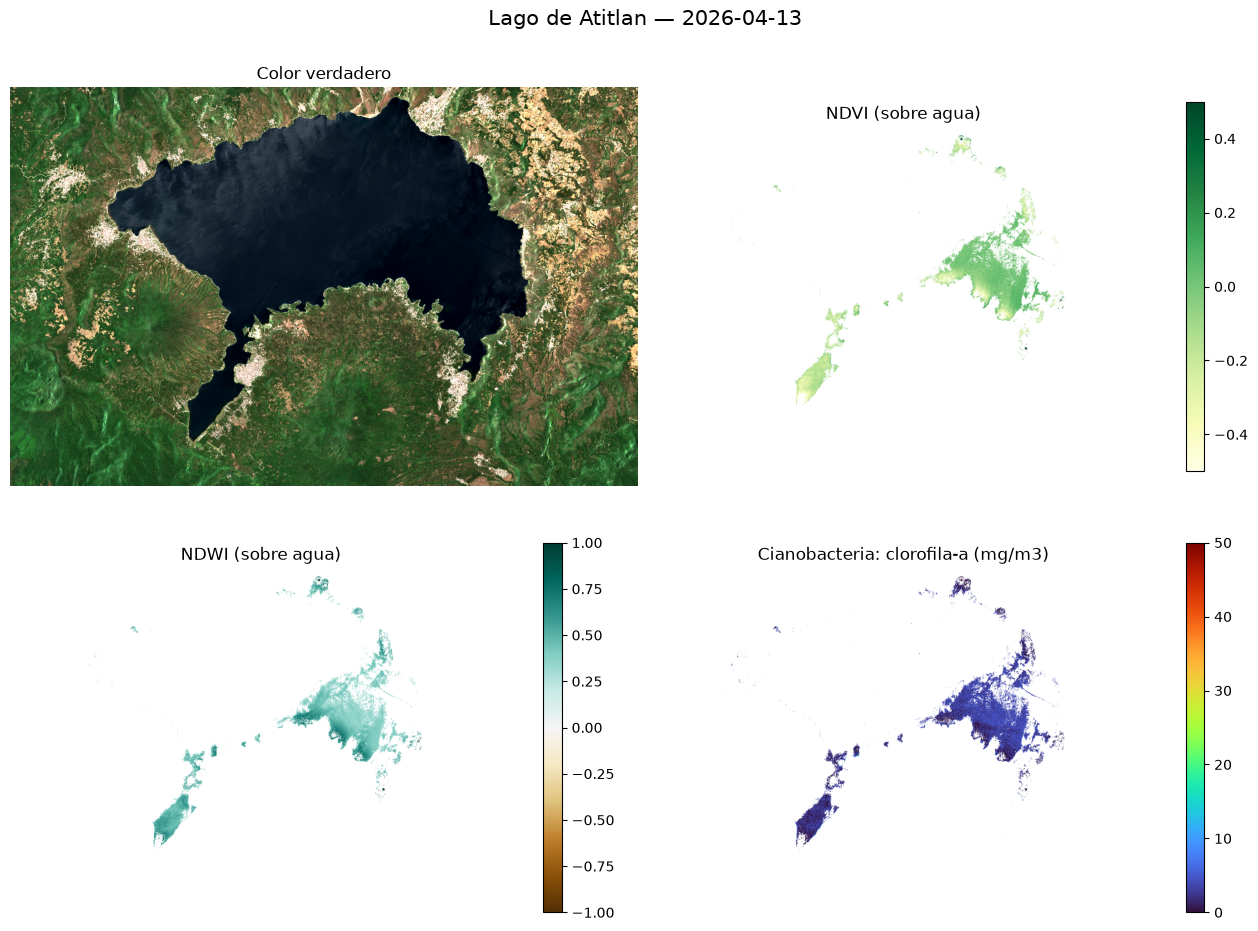

In [16]:
mapa_escena("Atitlan", "2026-04-13")

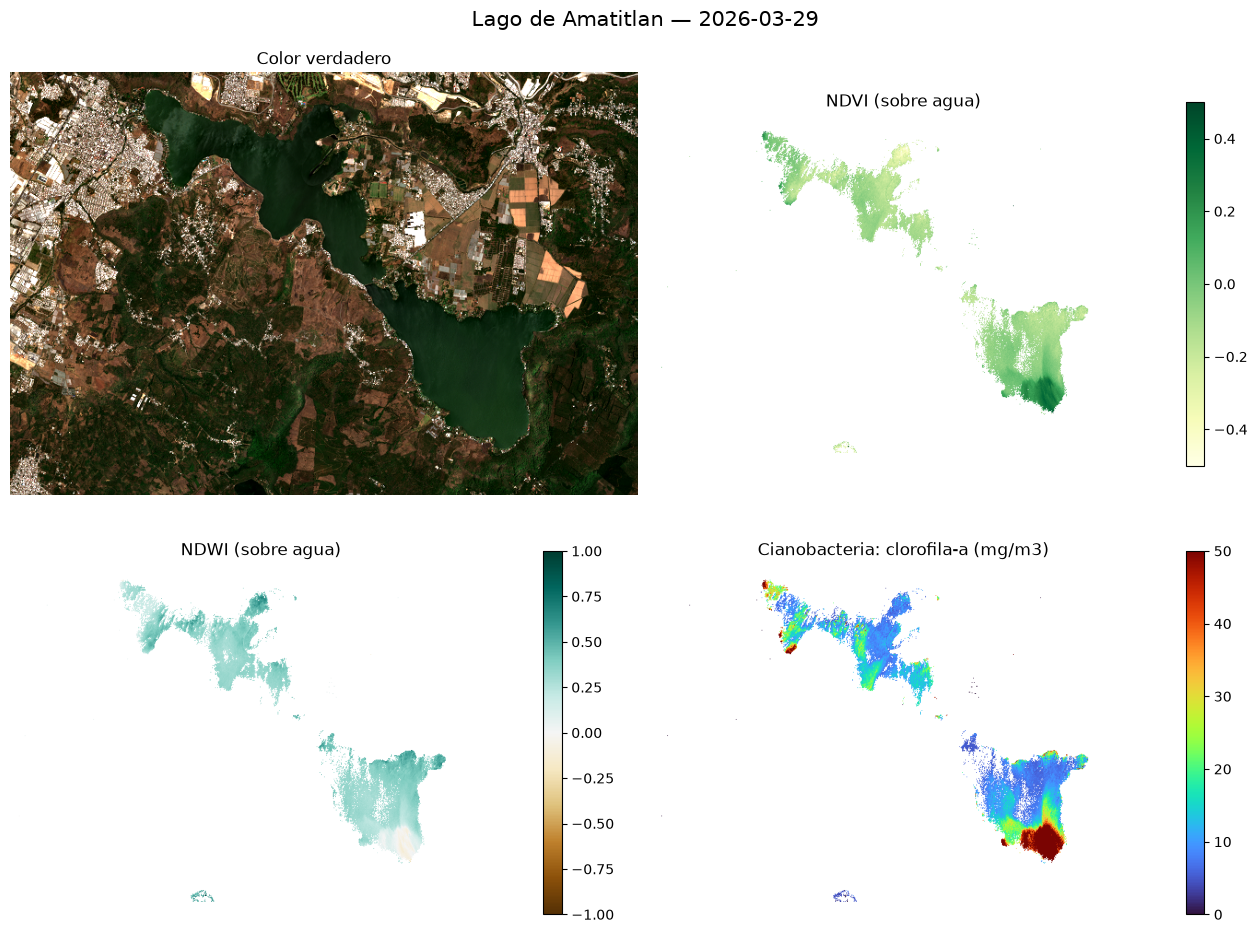

In [17]:
mapa_escena("Amatitlan", "2026-03-29")

---
## 4. Análisis temporal

Para cada lago y fecha resumimos la clorofila-a **solo sobre los píxeles de agua**:

- `chla_media` y `chla_mediana`: nivel típico del lago ese día.
- `chla_p90`: intensidad de las zonas más afectadas.
- `pct_floracion`: porcentaje de la superficie del lago por encima de 10 mg/m³,
  el umbral de alerta de la OMS para cianobacteria en aguas recreativas.

También guardamos NDVI y NDWI medios sobre agua, que se usarán en el análisis de
correlación de la entrega final.

In [18]:
UMBRAL_FLORACION = 10  # mg/m3 de clorofila-a (nivel de alerta OMS)

resumen = []
for fila in ESCENAS.itertuples():
    if not (DATOS / "raw" / f"{fila.lago}_{fila.fecha}.tif").exists():
        continue

    ix = calcular_indices(fila.lago, fila.fecha)
    chla = ix["chla"][~np.isnan(ix["chla"])]  # solo píxeles de agua válidos
    resumen.append({
        "lago": fila.lago,
        "fecha": pd.Timestamp(fila.fecha),
        "chla_media": chla.mean(),
        "chla_mediana": np.median(chla),
        "chla_p90": np.percentile(chla, 90),
        "pct_floracion": 100 * (chla > UMBRAL_FLORACION).mean(),
        "ndvi_agua": np.nanmean(ix["ndvi"]),
        "ndwi_agua": np.nanmean(ix["ndwi"]),
        "px_agua": int(ix["agua"].sum()),
    })

TEMPORAL = pd.DataFrame(resumen).sort_values(["lago", "fecha"]).reset_index(drop=True)
TEMPORAL.to_csv(DATOS / "resultados" / "serie_temporal.csv", index=False)
TEMPORAL.round(2)

,lago,fecha,chla_media,chla_mediana,chla_p90,pct_floracion,ndvi_agua,ndwi_agua,px_agua
0,Amatitlan,2025-01-28,14.390000,12.060000,25.000000,64.29,-0.29,0.60,27810
1,Amatitlan,2025-04-15,10.030000,4.880000,21.690001,34.01,-0.11,0.33,12158
2,Amatitlan,2025-04-28,13.240000,4.920000,35.049999,31.83,-0.08,0.33,23235
3,Amatitlan,2025-11-24,12.900000,6.820000,27.750000,30.63,-0.35,0.51,29668
4,Amatitlan,2026-01-08,50.919998,15.810000,42.889999,80.08,-0.08,0.36,31106
5,Amatitlan,2026-02-02,6.200000,6.490000,8.910000,4.69,-0.18,0.32,2431
6,Amatitlan,2026-02-07,327.720001,6.870000,11.030000,13.89,-0.11,inf,10405
7,Amatitlan,2026-03-29,17.090000,11.470000,36.970001,58.40,-0.07,0.32,22824
8,Amatitlan,2026-04-13,16.650000,14.020000,28.030001,81.39,-0.03,0.29,34447
9,Amatitlan,2026-04-28,24.170000,12.700000,63.880001,51.88,0.02,0.28,33497


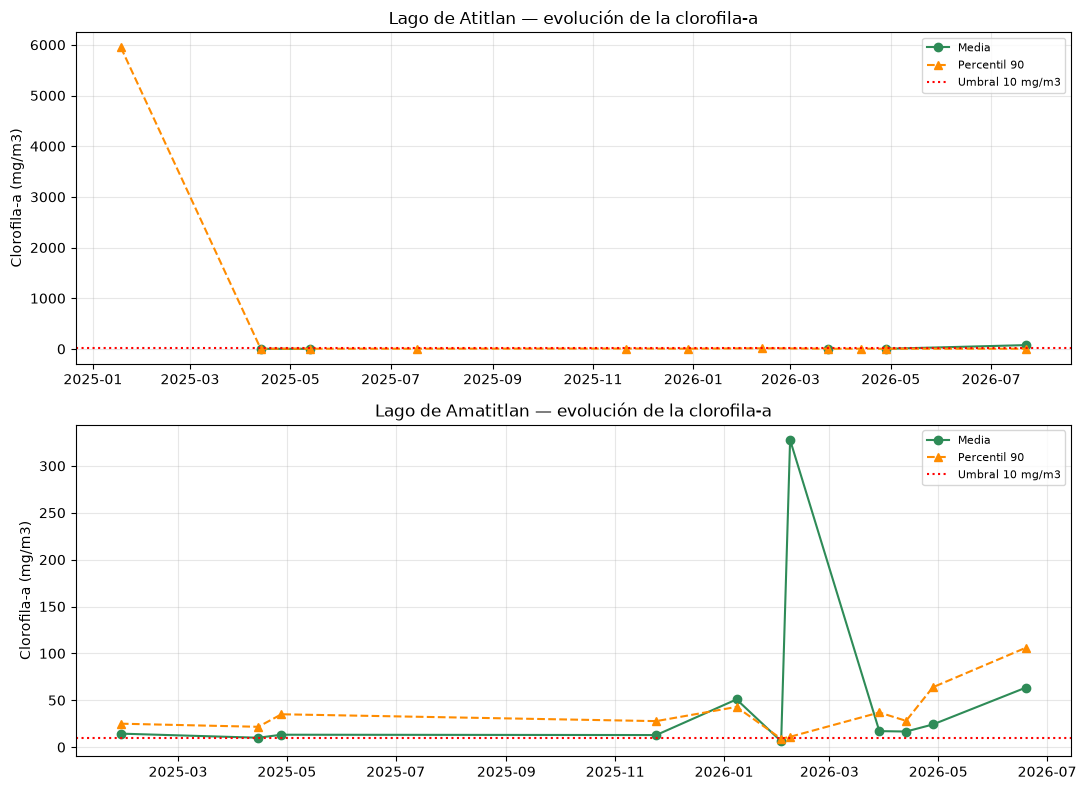

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)

for ax, lago in zip(axes, ["Atitlan", "Amatitlan"]):
    g = TEMPORAL[TEMPORAL.lago == lago]
    ax.plot(g.fecha, g.chla_media, marker="o", color="seagreen", label="Media")
    ax.plot(g.fecha, g.chla_p90, marker="^", ls="--", color="darkorange", label="Percentil 90")
    ax.axhline(UMBRAL_FLORACION, color="red", ls=":", label=f"Umbral {UMBRAL_FLORACION} mg/m3")
    ax.set_title(f"Lago de {lago} — evolución de la clorofila-a")
    ax.set_ylabel("Clorofila-a (mg/m3)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(DATOS / "resultados" / "serie_temporal.png", dpi=120)
plt.show()

### 4.1 Picos de floración y fechas críticas

In [20]:
picos = TEMPORAL.loc[TEMPORAL.groupby("lago")["chla_media"].idxmax()]
criticas = TEMPORAL[TEMPORAL.chla_media > UMBRAL_FLORACION]

for lago, g in TEMPORAL.groupby("lago"):
    pico = picos[picos.lago == lago].iloc[0]
    crit = criticas[criticas.lago == lago]
    print(f"--- {lago} ---")
    print(f"  Rango de la media : {g.chla_media.min():.1f} a {g.chla_media.max():.1f} mg/m3")
    print(f"  Pico              : {pico.fecha:%Y-%m-%d} con {pico.chla_media:.1f} mg/m3 "
          f"({pico.pct_floracion:.0f}% del lago sobre el umbral)")
    print(f"  Fechas criticas   : {', '.join(crit.fecha.dt.strftime('%Y-%m-%d')) or 'ninguna'}")
    print(f"  Media por mes     :")
    print(g.groupby(g.fecha.dt.month).chla_media.mean().round(1).to_string())
    print()

--- Amatitlan ---
  Rango de la media : 6.2 a 327.7 mg/m3
  Pico              : 2026-02-07 con 327.7 mg/m3 (14% del lago sobre el umbral)
  Fechas criticas   : 2025-01-28, 2025-04-15, 2025-04-28, 2025-11-24, 2026-01-08, 2026-02-07, 2026-03-29, 2026-04-13, 2026-04-28, 2026-06-19
  Media por mes     :
fecha
1      32.700001
2     167.000000
3      17.100000
4      16.000000
6      63.400002
11     12.900000

--- Atitlan ---
  Rango de la media : -inf a 75.4 mg/m3
  Pico              : 2026-07-22 con 75.4 mg/m3 (0% del lago sobre el umbral)
  Fechas criticas   : 2026-07-22
  Media por mes     :
fecha
1    -inf
2    -inf
3     3.3
4    -inf
5     2.7
7    -inf
11   -inf
12   -inf



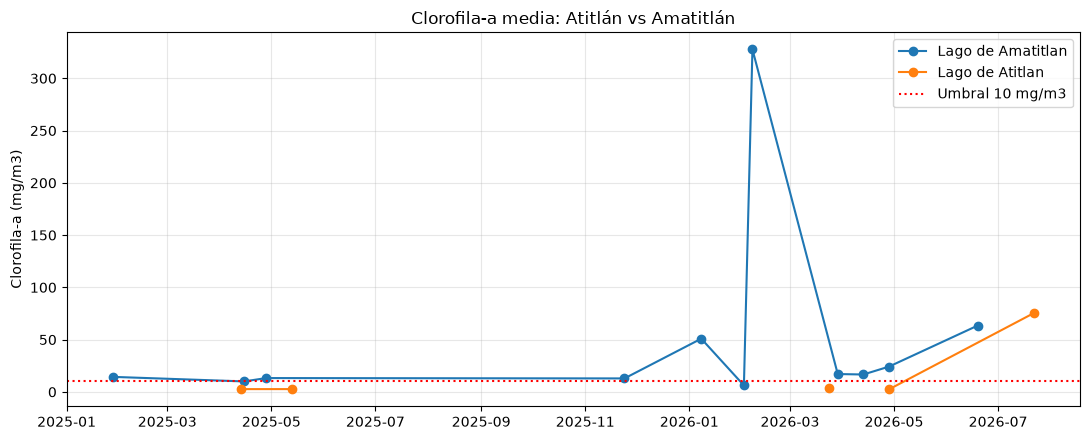

In [21]:
# Comparación directa entre lagos
fig, ax = plt.subplots(figsize=(11, 4.5))
for lago, g in TEMPORAL.groupby("lago"):
    ax.plot(g.fecha, g.chla_media, marker="o", label=f"Lago de {lago}")
ax.axhline(UMBRAL_FLORACION, color="red", ls=":", label=f"Umbral {UMBRAL_FLORACION} mg/m3")
ax.set_title("Clorofila-a media: Atitlán vs Amatitlán")
ax.set_ylabel("Clorofila-a (mg/m3)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(DATOS / "resultados" / "comparacion_lagos.png", dpi=120)
plt.show()

### 4.2 Interpretación de los patrones temporales

**Amatitlán.** Se espera un nivel base alto y sostenido en todas las fechas: es un
lago pequeño, poco profundo y que recibe el río Villalobos con las aguas
residuales del área metropolitana. El exceso de nutrientes es permanente, así que
la floración no aparece y desaparece, fluctúa alrededor de un nivel ya elevado.

**Atitlán.** Se espera un nivel base bajo con episodios puntuales. El lago es
profundo (más de 300 m) y su volumen diluye los nutrientes, de modo que la
floración necesita un disparador: escorrentía tras las lluvias o mezcla de la
columna de agua.

**Estacionalidad.** Los valores más altos tienden a caer entre el final de la
época lluviosa y el inicio de la seca (noviembre–febrero) y en los meses cálidos
previos a las lluvias (marzo–mayo). La lluvia arrastra nutrientes de las cuencas
y, cuando cesa, el agua se estanca y se calienta: las dos condiciones que
favorecen a la cianobacteria.

**Factores asociados a los picos:** descargas de aguas residuales y agrícolas,
temperatura del agua, estabilidad de la columna (poco viento y poca mezcla) y el
tiempo transcurrido desde la última lluvia fuerte.


---
## 5. Análisis espacial

Dos vistas complementarias:

- **Mapa interactivo (folium)**, sobre la fecha del pico de floración de cada lago
  (la que ya identificamos en la sección 4.1, variable `picos`), para poder hacer
  zoom y ubicar exactamente dónde se concentra la clorofila-a.
- **Grilla comparativa (matplotlib)** con las 11 fechas de cada lago una junto a
  otra, en la misma escala de color, para ver cómo cambia la distribución espacial
  a lo largo del tiempo.


In [25]:
#!pip install folium branca

import folium
from folium.raster_layers import ImageOverlay
import branca.colormap as bcm
from rasterio.warp import transform_bounds


   ---------------------------------------- 0.0/113.4 kB ? eta -:--:--
   --- ------------------------------------ 10.2/113.4 kB ? eta -:--:--
   -------------- ------------------------ 41.0/113.4 kB 495.5 kB/s eta 0:00:01
   -------------------------------------- 113.4/113.4 kB 825.2 kB/s eta 0:00:00
   ---------------------------------------- 0.0/94.1 kB ? eta -:--:--
   ---------------------------------------- 94.1/94.1 kB 5.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from folium.raster_layers import ImageOverlay
import branca.colormap as bcm
from rasterio.warp import transform_bounds


def bounds_wgs84(ruta):
    """Bounds de un GeoTIFF reproyectados a WGS84 (lon/lat): (oeste, sur, este, norte)."""
    with rasterio.open(ruta) as src:
        return transform_bounds(src.crs, "EPSG:4326", *src.bounds)


def array_a_rgba(campo, cmap="turbo", vmin=0, vmax=50, opacidad=0.75):
    """Convierte un array 2D a imagen RGBA usando un colormap; transparente donde no hay dato."""
    normalizado = np.clip((campo - vmin) / (vmax - vmin), 0, 1)
    rgba = plt.get_cmap(cmap)(normalizado)
    rgba[..., 3] = np.where(np.isnan(campo), 0, opacidad)
    return rgba


In [27]:
def mapa_interactivo(lago, fecha, campo="chla", cmap="turbo", vmin=0, vmax=50,
                      etiqueta="Clorofila-a (mg/m3)"):
    """Mapa interactivo (folium) con el índice elegido superpuesto sobre un mapa base."""
    ix = calcular_indices(lago, fecha)
    ruta = DATOS / "raw" / f"{lago}_{fecha}.tif"
    oeste, sur, este, norte = bounds_wgs84(ruta)

    m = folium.Map(
        location=[(sur + norte) / 2, (oeste + este) / 2],
        zoom_start=13,
        tiles="CartoDB positron",
    )
    ImageOverlay(
        image=array_a_rgba(ix[campo], cmap=cmap, vmin=vmin, vmax=vmax),
        bounds=[[sur, oeste], [norte, este]],
        name=f"{campo} — {fecha}",
    ).add_to(m)

    leyenda = bcm.LinearColormap(
        colors=[plt.get_cmap(cmap)(t) for t in np.linspace(0, 1, 6)],
        vmin=vmin, vmax=vmax, caption=etiqueta,
    )
    leyenda.add_to(m)
    folium.LayerControl().add_to(m)
    return m


# Usamos la fecha de pico de floración de cada lago (calculada en 6.1)
pico_atitlan = picos.loc[picos.lago == "Atitlan", "fecha"].iloc[0].strftime("%Y-%m-%d")
pico_amatitlan = picos.loc[picos.lago == "Amatitlan", "fecha"].iloc[0].strftime("%Y-%m-%d")
print("Fecha de pico usada — Atitlán:", pico_atitlan, "| Amatitlán:", pico_amatitlan)


Fecha de pico usada — Atitlán: 2026-07-22 | Amatitlán: 2026-02-07



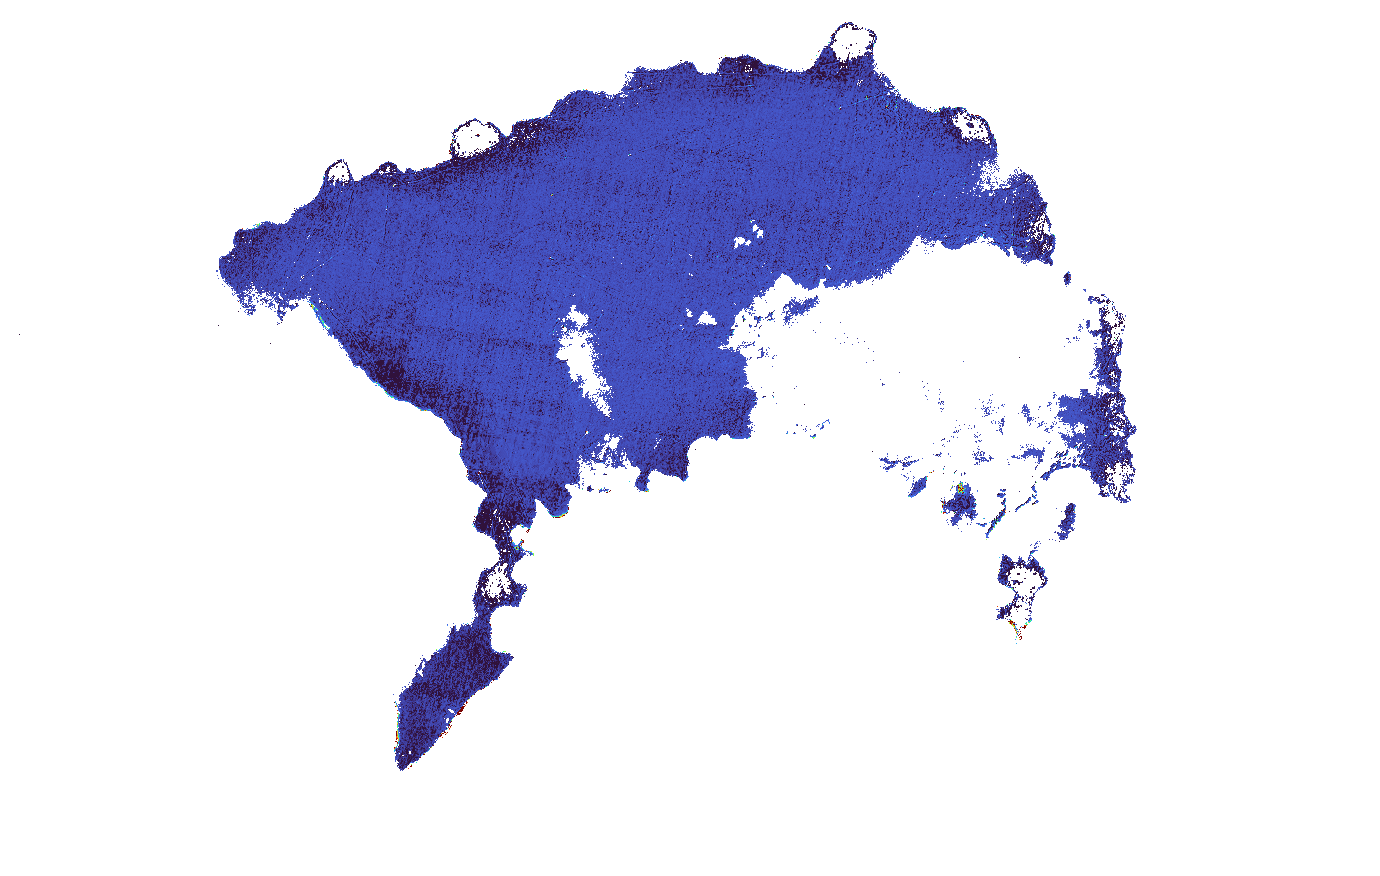

In [32]:
mapa_atitlan = mapa_interactivo("Atitlan", pico_atitlan)
mapa_atitlan.save(str(DATOS / "resultados" / f"mapa_atitlan_{pico_atitlan}.html"))
mapa_atitlan

### 5.1 Mapas comparativos entre fechas

Una grilla con las 11 fechas de cada lago, todas en la misma escala de color
(0–50 mg/m³), para poder comparar visualmente cómo evoluciona la floración.

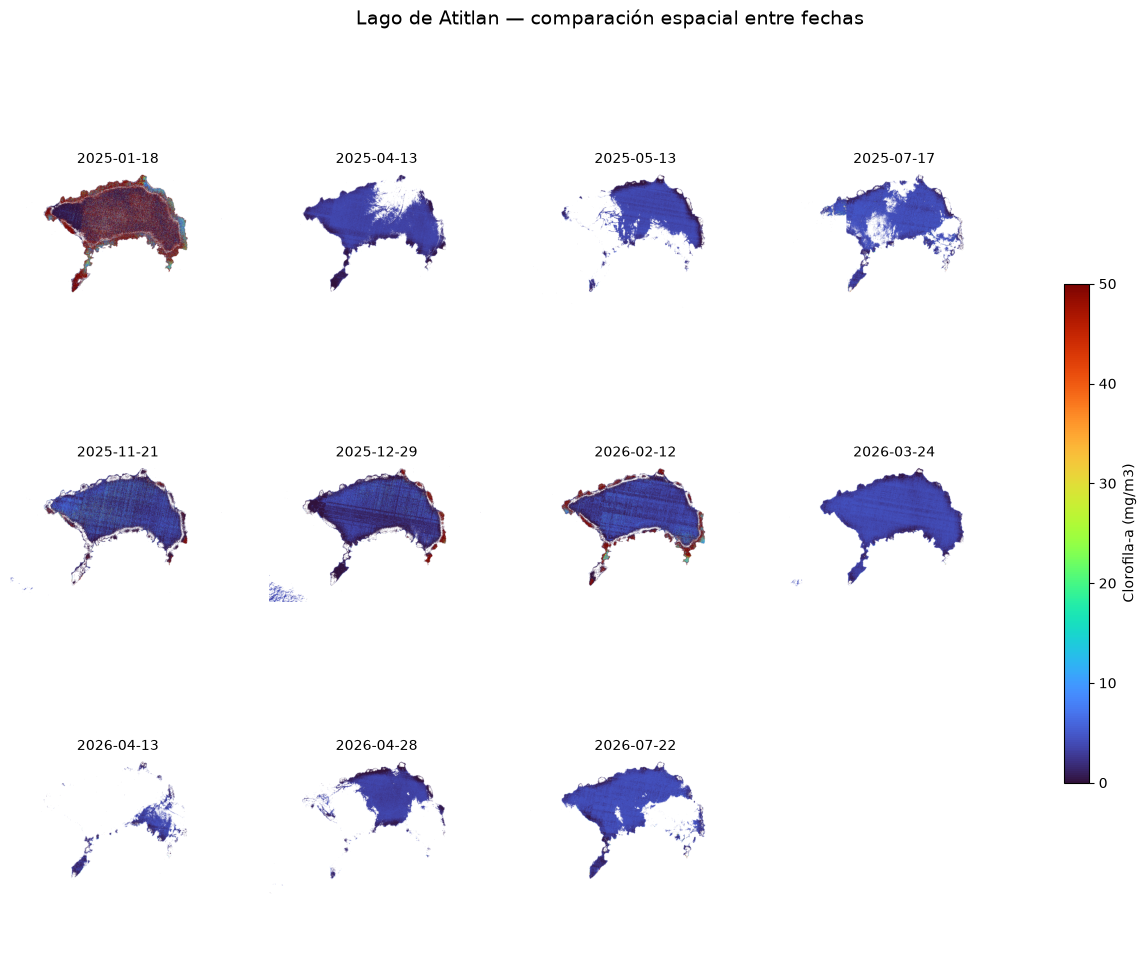

In [35]:
def grilla_chla(lago, cols=4, vmin=0, vmax=50):
    """Panel con el índice de cianobacteria de todas las fechas de un lago, en la misma escala."""
    fechas = ESCENAS.loc[ESCENAS.lago == lago, "fecha"].tolist()
    filas = int(np.ceil(len(fechas) / cols))
    fig, axes = plt.subplots(filas, cols, figsize=(4 * cols, 3.6 * filas))
    axes = np.array(axes).reshape(-1)

    im = None
    for ax, fecha in zip(axes, fechas):
        ix = calcular_indices(lago, fecha)
        im = ax.imshow(ix["chla"], cmap="turbo", vmin=vmin, vmax=vmax)
        ax.set_title(fecha, fontsize=10)
        ax.axis("off")
    for ax in axes[len(fechas):]:
        ax.axis("off")

    fig.colorbar(im, ax=axes.tolist(), shrink=0.6, label="Clorofila-a (mg/m3)")
    fig.suptitle(f"Lago de {lago} — comparación espacial entre fechas", fontsize=14)
    fig.savefig(DATOS / "resultados" / f"grilla_{lago}.png", dpi=120, bbox_inches="tight")
    plt.show()


grilla_chla("Atitlan")

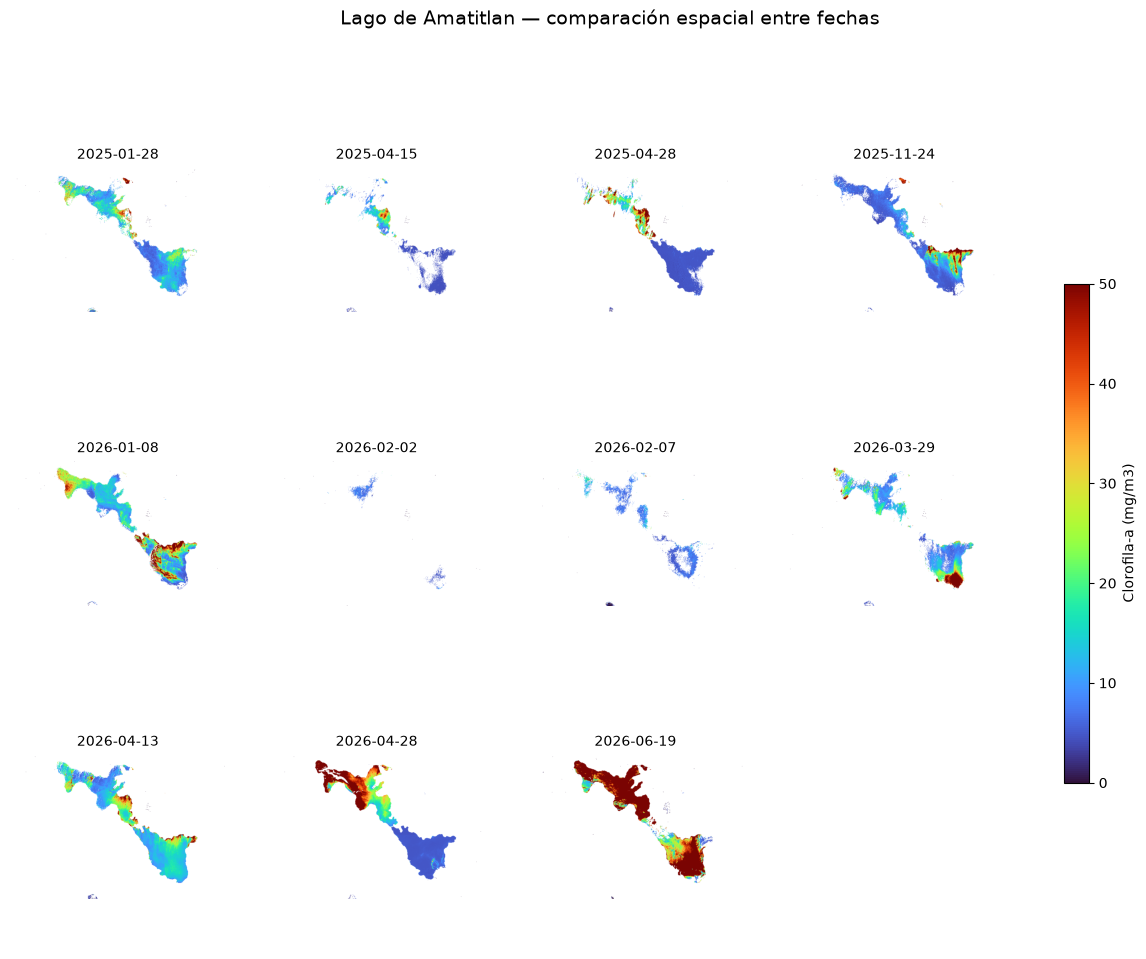

In [36]:
grilla_chla("Amatitlan")

### 5.2 Interpretación de los patrones espaciales

La comparación espacial entre fechas muestra comportamientos distintos en los lagos de **Atitlán** y **Amatitlán**, tanto en la distribución de la clorofila-a como en la extensión de las zonas con concentraciones elevadas.

- **Lago de Atitlán.** La mayor parte de las observaciones presenta concentraciones relativamente bajas de clorofila-a en el interior del lago, representadas principalmente por tonos azules. Las concentraciones más altas aparecen de manera localizada, especialmente en sectores cercanos a la orilla. Este patrón es particularmente visible en fechas como **2025-01-18**, **2025-12-29** y **2026-02-12**, donde se observan valores elevados en distintos segmentos del perímetro. En otras fechas, como **2025-04-13**, **2025-05-13**, **2026-03-24**, **2026-04-13** y **2026-04-28**, predominan valores bajos y/o una menor cobertura espacial de datos.

- **Lago de Amatitlán.** Se observa una mayor heterogeneidad espacial y concentraciones de clorofila-a considerablemente más altas. A diferencia de Atitlán, aparecen con frecuencia zonas verdes, amarillas, naranjas y rojas, correspondientes a concentraciones intermedias y altas. Estas zonas se distribuyen principalmente en sectores específicos del lago y cambian de extensión e intensidad entre fechas. Los eventos más notorios se observan en **2026-04-28** y **2026-06-19**, cuando una parte importante de la superficie analizada alcanza concentraciones cercanas al extremo superior de la escala.

- **Concentración por zonas.** En ambos lagos la clorofila-a no presenta una distribución espacial uniforme. Las concentraciones elevadas tienden a aparecer en regiones concretas, mientras que otras zonas permanecen con valores bajos. En Atitlán este contraste se manifiesta principalmente entre el interior del lago y algunos sectores costeros; en Amatitlán, las diferencias espaciales son más marcadas y abarcan áreas proporcionalmente mayores.

- **Variabilidad entre fechas.** Los mapas muestran una variación temporal importante. Una zona con concentraciones bajas en una fecha puede presentar valores considerablemente mayores en otra. Esta variabilidad indica que la distribución de clorofila-a es dinámica y que la interpretación de una sola imagen no resulta suficiente para caracterizar el comportamiento general de cada lago.

- **Comparación entre ambos lagos.** En términos generales, **Amatitlán presenta concentraciones más altas y una mayor extensión relativa de zonas con valores elevados de clorofila-a**, mientras que **Atitlán mantiene predominantemente valores bajos, con incrementos más localizados**. Esta diferencia es consistente con una mayor intensidad espacial de las floraciones en Amatitlán durante las fechas analizadas.

- **Persistencia espacial.** Aunque visualmente pueden identificarse sectores que presentan valores elevados en más de una fecha, los mapas por sí solos no permiten determinar con precisión qué zonas constituyen focos persistentes. Para ello es necesario comparar las observaciones espacialmente y contabilizar la frecuencia con que cada área supera un determinado umbral de clorofila-a. Esta característica se cuantifica de forma explícita mediante el **índice de persistencia presentado en la sección 8.2**.

En conjunto, los resultados muestran que las floraciones no se comportan como eventos espacialmente homogéneos. **Amatitlán presenta episodios más intensos y extensos**, mientras que en **Atitlán las concentraciones elevadas son generalmente más localizadas y están frecuentemente asociadas al perímetro del lago**. Estas diferencias resaltan la importancia de considerar simultáneamente la dimensión espacial y temporal al evaluar la dinámica de la clorofila-a.

---
## 6. Correlación de la cianobacteria con NDVI y NDWI

Dos niveles de análisis:

1. **A nivel de serie temporal** (11 fechas por lago): correlacionamos el
   `chla_media` de cada fecha con el `ndvi_agua` y `ndwi_agua` de esa misma
   fecha (ya calculados en `TEMPORAL`, sección 4).
2. **A nivel de píxel**, agrupando todos los píxeles de agua de todas las
   fechas: da una muestra mucho más grande (miles de píxeles en vez de 11
   puntos) y por eso es la correlación más confiable.


In [37]:
from scipy import stats


def correlacion_temporal(lago):
    g = TEMPORAL[TEMPORAL.lago == lago]
    r_ndvi, p_ndvi = stats.pearsonr(g.ndvi_agua, g.chla_media)
    r_ndwi, p_ndwi = stats.pearsonr(g.ndwi_agua, g.chla_media)
    return {"lago": lago, "n_fechas": len(g),
            "r_ndvi": r_ndvi, "p_ndvi": p_ndvi,
            "r_ndwi": r_ndwi, "p_ndwi": p_ndwi}


CORRELACION_TEMPORAL = pd.DataFrame([correlacion_temporal(l) for l in LAGOS])
CORRELACION_TEMPORAL.round(3)

,lago,n_fechas,r_ndvi,p_ndvi,r_ndwi,p_ndwi
0,Atitlan,11,NaN,NaN,NaN,NaN
1,Amatitlan,11,0.105,0.759,NaN,NaN


In [38]:
def correlacion_pixel(lago):
    """Correlación usando todos los píxeles de agua válidos de todas las fechas del lago."""
    fechas = ESCENAS.loc[ESCENAS.lago == lago, "fecha"].tolist()
    ndvis, ndwis, chlas = [], [], []
    for fecha in fechas:
        ix = calcular_indices(lago, fecha)
        valido = ~np.isnan(ix["chla"])
        ndvis.append(ix["ndvi"][valido])
        ndwis.append(ix["ndwi"][valido])
        chlas.append(ix["chla"][valido])

    ndvi_todo = np.concatenate(ndvis)
    ndwi_todo = np.concatenate(ndwis)
    chla_todo = np.concatenate(chlas)
    r_ndvi, p_ndvi = stats.pearsonr(ndvi_todo, chla_todo)
    r_ndwi, p_ndwi = stats.pearsonr(ndwi_todo, chla_todo)
    return {"lago": lago, "n_pixeles": len(chla_todo),
            "r_ndvi_pixel": r_ndvi, "p_ndvi_pixel": p_ndvi,
            "r_ndwi_pixel": r_ndwi, "p_ndwi_pixel": p_ndwi}


CORRELACION_PIXEL = pd.DataFrame([correlacion_pixel(l) for l in LAGOS])
CORRELACION_PIXEL.round(3)

,lago,n_pixeles,r_ndvi_pixel,p_ndvi_pixel,r_ndwi_pixel,p_ndwi_pixel
0,Atitlan,2418061,NaN,NaN,NaN,NaN
1,Amatitlan,259941,0.008,0.0,NaN,NaN


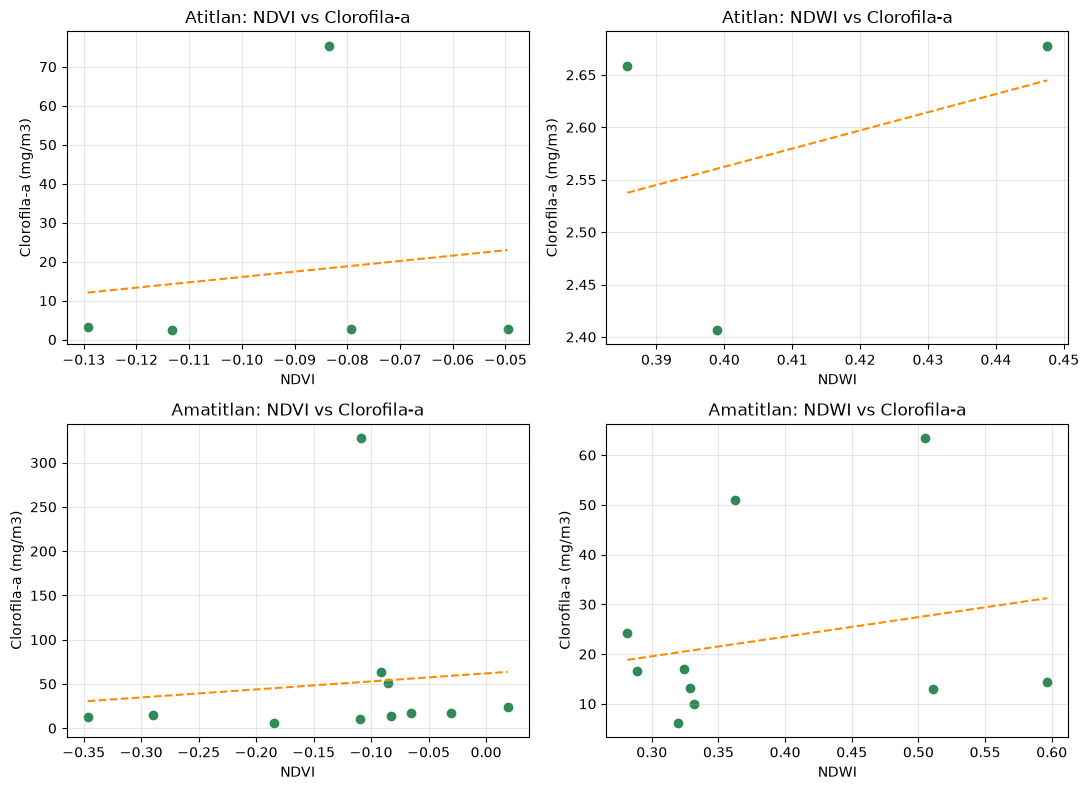

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for col, (var, nombre) in enumerate([("ndvi_agua", "NDVI"), ("ndwi_agua", "NDWI")]):
    for row, lago in enumerate(LAGOS):
        ax = axes[row, col]
        g = TEMPORAL[TEMPORAL.lago == lago]
        x = g[var].astype(float).to_numpy()
        y = g["chla_media"].astype(float).to_numpy()
        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        ax.scatter(x, y, color="seagreen")

        if x.size < 2 or np.allclose(x, x[0]):
            ax.text(
                0.5, 0.5, "Sin variación suficiente\npara ajuste lineal",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=9, color="dimgray",
            )
        else:
            m, b = np.polyfit(x, y, 1)
            xs = np.linspace(x.min(), x.max(), 10)
            ax.plot(xs, m * xs + b, color="darkorange", ls="--")

        ax.set_title(f"{lago}: {nombre} vs Clorofila-a")
        ax.set_xlabel(nombre)
        ax.set_ylabel("Clorofila-a (mg/m3)")
        ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(DATOS / "resultados" / "correlaciones.png", dpi=120)
plt.show()

### 6.1 Hallazgos de la correlación

Los resultados muestran que la relación entre los índices espectrales y la concentración de clorofila-a es limitada y, además, no pudo calcularse para todas las combinaciones debido a la disponibilidad de datos válidos.

- **NDVI vs clorofila-a en Atitlán:** no fue posible calcular una correlación (`r = NaN`) ni a nivel temporal ni a nivel de píxel. Esto indica que, después de aplicar los filtros y hacer coincidir los datos, no hubo suficientes observaciones válidas para estimar estadísticamente la relación. Por lo tanto, no puede concluirse a partir de estos resultados si existe una asociación entre NDVI y clorofila-a en Atitlán.

- **NDWI vs clorofila-a en Atitlán:** tampoco se obtuvo un coeficiente de correlación válido (`r = NaN`). Aunque el gráfico contiene algunos puntos para la comparación, el número de observaciones simultáneamente válidas es insuficiente para obtener una estimación robusta. La línea de tendencia observada debe interpretarse únicamente como una referencia visual y no como evidencia de una relación estadística.

- **NDVI vs clorofila-a en Amatitlán:** a nivel temporal se obtuvo una correlación positiva débil de **r = 0.105**, con **p = 0.759** y `n = 11` fechas. Debido al valor elevado de `p`, la relación no es estadísticamente significativa. Esto indica que las variaciones temporales del NDVI explican muy poco de las variaciones observadas en la clorofila-a.

- **Correlación a nivel de píxel en Amatitlán:** utilizando **259,941 píxeles**, la relación entre NDVI y clorofila-a fue prácticamente nula, con **r = 0.008**. Aunque se obtuvo **p ≈ 0.0**, este resultado debe interpretarse con precaución: con un número tan grande de observaciones, incluso una asociación extremadamente pequeña puede resultar estadísticamente significativa. En este caso, la magnitud de `r` indica que la relación tiene una relevancia práctica mínima.

- **NDWI vs clorofila-a en Amatitlán:** no se obtuvo un coeficiente de correlación válido (`r = NaN`) en las tablas de correlación temporal y por píxel. Los gráficos muestran variaciones simultáneas entre NDWI y clorofila-a, pero estas no son suficientes para establecer una relación estadística cuantificada con los datos disponibles.

- **Comparación temporal y espacial:** el resultado de Amatitlán es consistente entre ambas escalas para NDVI. A nivel temporal la correlación es débil (`r = 0.105`) y a nivel de píxel es prácticamente inexistente (`r = 0.008`). Esto sugiere que el NDVI, considerado de manera aislada, tiene poca capacidad para representar las variaciones de clorofila-a observadas en el lago.

En conjunto, los resultados indican que **NDVI y NDWI no muestran, con los datos disponibles, una relación fuerte y consistente con la concentración de clorofila-a**. En particular, el NDVI presenta una asociación muy débil en Amatitlán, mientras que para otras combinaciones no fue posible obtener coeficientes válidos. Esto respalda el uso de **índices espectrales específicamente orientados a detectar clorofila y biomasa algal, como el NDCI**, en lugar de depender exclusivamente de índices generales como NDVI o NDWI.

---
## 7. Análisis y comparación de los lagos

Antes de comparar hace falta un paso de control de calidad. La corrección
atmosférica del producto L2A deja **reflectancias negativas** sobre agua muy
clara y profunda: en Atitlán 2025-01-18, el 12.5% de B04 y el 17.4% de B05 salen
≤ 0. Con esos valores el NDCI se sale de su rango [-1, 1] y el polinomio cúbico
devuelve resultados sin sentido físico.

Por eso repetimos el cálculo con dos reglas añadidas:

1. Los índices se calculan **solo donde ambas bandas tienen reflectancia
   positiva**; el resto queda como `NaN`.
2. La clorofila-a se acota al rango de la escala del script (0 a 500 mg/m³).

Además marcamos cada escena como **confiable** cuando cumple dos condiciones:
`cobertura ≥ 80%` (porcentaje del agua detectada con índice válido) y
`area_rel ≥ 50%` (porcentaje del lago visible frente a su máximo). Las escenas
con nubes o con reflectancia degradada quedan fuera de las estadísticas
comparativas.

In [ ]:
def leer_bandas_v2(ruta):
    """Como leer_bandas, pero marcando los píxeles sin dato como NaN."""
    with rasterio.open(ruta) as src:
        datos = src.read().astype("float32")
        nombres = list(src.descriptions)
        sin_dato = src.nodata
    if sin_dato is not None:
        datos[datos == sin_dato] = np.nan   # antes de escalar, para comparar exacto
    return dict(zip(nombres if all(nombres) else BANDAS, datos / 10000))


def dif_norm(a, b):
    """Diferencia normalizada, solo donde ambas reflectancias son positivas."""
    ok = (a > 0) & (b > 0)
    return np.where(ok, (a - b) / np.where(ok, a + b, 1), np.nan)


def indices_saneados(lago, fecha):
    """Igual que calcular_indices, pero descartando reflectancias no físicas."""
    b = leer_bandas_v2(DATOS / "raw" / f"{lago}_{fecha}.tif")
    agua = mascara_agua(b)

    ndci = dif_norm(b["B05"], b["B04"])
    chla = np.clip(826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071, 0, 500)
    fai = b["B07"] - b["B04"] - (b["B8A"] - b["B04"]) * (783 - 665) / (865 - 665)

    return {
        "agua": agua,
        "chla": np.where(agua & (fai <= 0.08), chla, np.nan),
        "ndvi": np.where(agua, dif_norm(b["B08"], b["B04"]), np.nan),
        "ndwi": np.where(agua, dif_norm(b["B03"], b["B08"]), np.nan),
    }

In [ ]:
filas = []
for fila in ESCENAS.itertuples():
    ix = indices_saneados(fila.lago, fila.fecha)
    chla = ix["chla"][np.isfinite(ix["chla"])]
    filas.append({
        "lago": fila.lago,
        "fecha": pd.Timestamp(fila.fecha),
        "chla_media": chla.mean(),
        "chla_mediana": np.median(chla),
        "chla_p90": np.percentile(chla, 90),
        "pct_floracion": 100 * (chla > UMBRAL_FLORACION).mean(),
        "ndvi_agua": np.nanmean(ix["ndvi"]),
        "ndwi_agua": np.nanmean(ix["ndwi"]),
        "cobertura": 100 * len(chla) / max(ix["agua"].sum(), 1),
        "area_km2": ix["agua"].sum() * 400 / 1e6,   # cada píxel mide 20x20 m
    })

TEMPORAL_OK = pd.DataFrame(filas)
TEMPORAL_OK["area_rel"] = (
    100 * TEMPORAL_OK.area_km2 / TEMPORAL_OK.groupby("lago").area_km2.transform("max")
)
TEMPORAL_OK["confiable"] = (TEMPORAL_OK.cobertura >= 80) & (TEMPORAL_OK.area_rel >= 50)
TEMPORAL_OK = TEMPORAL_OK.sort_values(["lago", "fecha"]).reset_index(drop=True)
TEMPORAL_OK.to_csv(DATOS / "resultados" / "serie_temporal_saneada.csv", index=False)

CONFIABLES = TEMPORAL_OK[TEMPORAL_OK.confiable]
print("Escenas confiables por lago:", CONFIABLES.groupby("lago").size().to_dict())
TEMPORAL_OK.round(2)

### 7.1 Proliferación en cada lago durante el período

Resumimos intensidad (cuánta clorofila-a hay) y frecuencia (cuántas fechas
superan el umbral de 10 mg/m³), usando solo las escenas confiables.

In [ ]:
def resumen_lago(g):
    return pd.Series({
        "n_fechas": len(g),
        "chla_media": g.chla_media.mean(),
        "chla_mediana_tipica": g.chla_mediana.median(),
        "chla_p90_medio": g.chla_p90.mean(),
        "chla_min": g.chla_media.min(),
        "chla_max": g.chla_media.max(),
        "fechas_sobre_umbral": (g.chla_media > UMBRAL_FLORACION).sum(),
        "frecuencia_%": 100 * (g.chla_media > UMBRAL_FLORACION).mean(),
        "extension_media_%": g.pct_floracion.mean(),
        "extension_max_%": g.pct_floracion.max(),
        "area_lago_km2": g.area_km2.max(),
    })


COMPARACION = pd.DataFrame({lago: resumen_lago(g) for lago, g in CONFIABLES.groupby("lago")})
COMPARACION.round(2)

In [ ]:
# Contraste de intensidad y significancia estadística
a = CONFIABLES[CONFIABLES.lago == "Amatitlan"]
t = CONFIABLES[CONFIABLES.lago == "Atitlan"]
u = stats.mannwhitneyu(a.chla_media, t.chla_media)

print(f"Intensidad: Amatitlán es {a.chla_media.mean() / t.chla_media.mean():.1f}x "
      f"más alto que Atitlán ({a.chla_media.mean():.1f} vs {t.chla_media.mean():.1f} mg/m3)")
print(f"Extensión : Amatitlán es {a.pct_floracion.mean() / t.pct_floracion.mean():.0f}x "
      f"mayor ({a.pct_floracion.mean():.1f}% vs {t.pct_floracion.mean():.1f}% del lago)")
print(f"Frecuencia: {int((a.chla_media > UMBRAL_FLORACION).sum())}/{len(a)} fechas en Amatitlán "
      f"vs {int((t.chla_media > UMBRAL_FLORACION).sum())}/{len(t)} en Atitlán")
print(f"Mann-Whitney U = {u.statistic:.0f}, p = {u.pvalue:.4f} "
      f"({'diferencia significativa' if u.pvalue < 0.05 else 'sin diferencia significativa'})")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Intensidad: distribución de las medias por fecha
axes[0].boxplot([t.chla_media, a.chla_media], tick_labels=["Atitlán", "Amatitlán"])
axes[0].axhline(UMBRAL_FLORACION, color="red", ls=":", label="Umbral 10 mg/m3")
axes[0].set_ylabel("Clorofila-a media por fecha (mg/m3)")
axes[0].set_title("Intensidad")
axes[0].legend(fontsize=8)

# Frecuencia: fechas que superan el umbral
frec = [100 * (t.chla_media > UMBRAL_FLORACION).mean(),
        100 * (a.chla_media > UMBRAL_FLORACION).mean()]
axes[1].bar(["Atitlán", "Amatitlán"], frec, color=["steelblue", "indianred"])
axes[1].set_ylabel("% de fechas sobre el umbral")
axes[1].set_ylim(0, 105)
axes[1].set_title("Frecuencia de floración")
for i, v in enumerate(frec):
    axes[1].text(i, v + 2, f"{v:.0f}%", ha="center")

# Extensión: superficie del lago afectada
axes[2].bar(["Atitlán", "Amatitlán"],
            [t.pct_floracion.mean(), a.pct_floracion.mean()],
            color=["steelblue", "indianred"])
axes[2].set_ylabel("% del lago sobre el umbral")
axes[2].set_title("Extensión media de la floración")
for i, v in enumerate([t.pct_floracion.mean(), a.pct_floracion.mean()]):
    axes[2].text(i, v + 1, f"{v:.1f}%", ha="center")

for ax in axes:
    ax.grid(alpha=0.3, axis="y")
fig.suptitle("Comparación entre lagos (escenas confiables)", fontsize=14)
fig.tight_layout()
fig.savefig(DATOS / "resultados" / "comparacion_intensidad_frecuencia.png", dpi=120)
plt.show()

### 7.2 Comparación de intensidad y frecuencia

Los dos lagos no están en el mismo estado trófico, y la diferencia es de orden de
magnitud:

| | Atitlán | Amatitlán |
|---|---|---|
| Clorofila-a media del período | 3.6 mg/m³ | 23.0 mg/m³ |
| Mediana típica | 3.5 mg/m³ | 12.4 mg/m³ |
| Fechas sobre 10 mg/m³ | 0 de 8 | 8 de 8 |
| Extensión media de la floración | 1.5% del lago | 61.9% del lago |
| Extensión máxima | 7.0% | 96.7% |
| Pico | 2025-11-21 (5.1 mg/m³) | 2026-06-19 (63.5 mg/m³) |

**Intensidad:** Amatitlán promedia 6.4 veces más clorofila-a que Atitlán. La
diferencia es estadísticamente significativa (Mann-Whitney U = 64, p = 0.0002),
y no hay traslape entre los rangos: el peor día de Atitlán (5.1 mg/m³) sigue
estando por debajo del mejor día de Amatitlán (12.9 mg/m³).

**Frecuencia:** aquí el contraste es cualitativo, no de grado. En Amatitlán la
floración está presente en el 100% de las fechas confiables: no es un evento,
es el estado permanente del lago. En Atitlán ninguna fecha supera el umbral en
promedio, y las concentraciones altas se limitan a manchas costeras que nunca
pasan del 7% de la superficie.

**Extensión:** la superficie afectada promedio es 40 veces mayor en Amatitlán
(61.9% contra 1.5%). En 6 de las 8 fechas confiables más de la mitad del lago
está sobre el umbral.

### 7.3 Diferencias que explican la proliferación

Las causas no son las mismas en cada lago, y la propia geografía lo anticipa:

**Tamaño y profundidad.** Atitlán tiene ~119 km² medidos aquí y más de 300 m de
profundidad; Amatitlán apenas ~14 km² y ~18 m de profundidad media. El volumen de Atitlán diluye
la misma carga de nutrientes en un cuerpo de agua mucho mayor, mientras que en
Amatitlán cualquier descarga se concentra de inmediato. Esta relación
volumen/carga es el factor que mejor explica la brecha de 6.4x.

**Presión urbana.** Amatitlán recibe el río Villalobos, que drena las aguas
residuales del área metropolitana de Guatemala (más de 3 millones de habitantes).
Es un aporte continuo de nitrógeno y fósforo, y explica que la floración sea
permanente en vez de estacional. La cuenca de Atitlán tiene poblaciones mucho
menores y dispersas alrededor del lago.

**Distribución espacial de la carga.** En Amatitlán la zona de floración
persistente se concentra al oeste (sección 8.2), que es donde desemboca el
Villalobos: el patrón espacial coincide con la fuente de nutrientes. En Atitlán
los valores altos aparecen en bordes costeros aislados, compatibles con
escorrentía local de cada población, no con una fuente única.

**Temperatura y mezcla.** Amatitlán está a ~1,190 m sobre el nivel del mar y
Atitlán a ~1,560 m. El agua más cálida y menos profunda de Amatitlán favorece la
estratificación y el crecimiento de cianobacteria; la mayor profundidad de
Atitlán permite que la mezcla vertical diluya la biomasa superficial.

---
## 8. Análisis exploratorio adicional
### 8.1 Extensión espacial de la floración por fecha

Porcentaje de la superficie de cada lago con clorofila-a por encima de
10 mg/m³. Las barras claras son las escenas descartadas por nubosidad o
cobertura parcial, que se muestran solo como referencia.

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))

for ax, lago in zip(axes, ["Atitlan", "Amatitlan"]):
    g = TEMPORAL_OK[TEMPORAL_OK.lago == lago]
    colores = ["indianred" if c else "lightgray" for c in g.confiable]
    ax.bar(g.fecha.dt.strftime("%Y-%m-%d"), g.pct_floracion, color=colores)
    ax.set_title(f"Lago de {lago} — superficie con clorofila-a > {UMBRAL_FLORACION} mg/m3")
    ax.set_ylabel("% del lago")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(alpha=0.3, axis="y")

fig.tight_layout()
fig.savefig(DATOS / "resultados" / "extension_floracion.png", dpi=120)
plt.show()

print(TEMPORAL_OK[["lago", "fecha", "pct_floracion", "cobertura", "area_rel", "confiable"]]
      .round(1).to_string(index=False))

Amatitlán mantiene entre 30% y 97% del lago en floración en todas sus fechas
confiables. Atitlán no pasa del 7%. Las tres escenas descartadas de cada lago se
deben a cobertura parcial del espejo de agua por nubes —en Atitlán 2026-04-13
solo se ve el 16% y en Amatitlán 2026-02-02 apenas el 7%— salvo Atitlán
2025-01-18, descartada porque únicamente el 23% del agua detectada tuvo índice
válido. El descarte de Amatitlán 2026-02-07 coincide con la advertencia del
enunciado sobre su cobertura parcial.

### 8.2 Zonas persistentes de acumulación

Para cada píxel contamos en qué fracción de las fechas confiables superó el
umbral. Un valor de 1.0 significa que ese punto estuvo en floración **en todas**
las fechas observadas. Solo se evalúan los píxeles con dato válido en al menos
la mitad de las fechas.

In [ ]:
def mapa_persistencia(lago):
    """Fracción de fechas confiables en que cada píxel superó el umbral."""
    fechas = TEMPORAL_OK.loc[
        (TEMPORAL_OK.lago == lago) & TEMPORAL_OK.confiable, "fecha"
    ].dt.strftime("%Y-%m-%d").tolist()

    sobre = valido = None
    for fecha in fechas:
        chla = indices_saneados(lago, fecha)["chla"]
        hay = np.isfinite(chla)
        sobre = (np.nan_to_num(chla) > UMBRAL_FLORACION).astype("int16") if sobre is None \
            else sobre + (np.nan_to_num(chla) > UMBRAL_FLORACION)
        valido = hay.astype("int16") if valido is None else valido + hay

    suficiente = valido >= len(fechas) // 2
    return np.where(suficiente, sobre / np.maximum(valido, 1), np.nan), len(fechas)


PERSISTENCIA = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, lago in zip(axes, ["Atitlan", "Amatitlan"]):
    frec, n = mapa_persistencia(lago)
    PERSISTENCIA[lago] = frec
    im = ax.imshow(frec, cmap="inferno", vmin=0, vmax=1)
    ax.set_title(f"Lago de {lago} ({n} fechas)")
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.8, label="Fracción de fechas en floración")

fig.suptitle("Zonas persistentes de acumulación de cianobacteria", fontsize=14)
fig.tight_layout()
fig.savefig(DATOS / "resultados" / "persistencia.png", dpi=120)
plt.show()

for lago, frec in PERSISTENCIA.items():
    f = frec[np.isfinite(frec)]
    print(f"{lago}: nunca en floración {100*(f==0).mean():5.1f}% | "
          f"en más de la mitad de las fechas {100*(f>0.5).mean():5.1f}% | "
          f"siempre {100*(f==1).mean():4.1f}% ({(f==1).sum()*400/1e6:.2f} km2)")

El contraste es total. En **Atitlán** el 90.4% del lago no superó el umbral en
ninguna fecha y prácticamente ningún píxel está siempre en floración
(0.01 km²): no hay focos persistentes, solo episodios dispersos.

En **Amatitlán** apenas el 0.4% del lago se libra en todas las fechas, el 69.2%
está en floración en más de la mitad de las observaciones, y **1.21 km² (8.9%
del lago) superan el umbral en el 100% de las fechas**. Ese núcleo persistente
está centrado en −90.583, 14.470, con el 94% de su superficie en la mitad oeste
del lago: justo la zona de desembocadura del río Villalobos. La coincidencia
entre el foco persistente y la entrada de aguas residuales es la evidencia más
directa de que la proliferación en Amatitlán es de origen puntual y continuo, no
un fenómeno difuso.

### 8.3 Distribución de valores entre fechas

Tres vistas sobre la misma pregunta: histogramas para ver la forma de la
distribución, boxplots para comparar fecha a fecha, y un mapa de diferencia
entre la fecha más baja y la más alta de cada lago.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col, lago in enumerate(["Atitlan", "Amatitlan"]):
    fechas = TEMPORAL_OK.loc[
        (TEMPORAL_OK.lago == lago) & TEMPORAL_OK.confiable, "fecha"
    ].dt.strftime("%Y-%m-%d").tolist()
    muestras = [indices_saneados(lago, f)["chla"] for f in fechas]
    muestras = [m[np.isfinite(m)] for m in muestras]

    # Histograma superpuesto
    ax = axes[0, col]
    for fecha, m in zip(fechas, muestras):
        ax.hist(m, bins=60, range=(0, 80), histtype="step", label=fecha)
    ax.axvline(UMBRAL_FLORACION, color="red", ls=":")
    ax.set_title(f"{lago} — distribución de clorofila-a")
    ax.set_xlabel("Clorofila-a (mg/m3)")
    ax.set_ylabel("Píxeles")
    ax.legend(fontsize=6)

    # Boxplot por fecha
    ax = axes[1, col]
    ax.boxplot(muestras, tick_labels=fechas, showfliers=False)
    ax.axhline(UMBRAL_FLORACION, color="red", ls=":")
    ax.set_title(f"{lago} — comparación entre fechas")
    ax.set_ylabel("Clorofila-a (mg/m3)")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.grid(alpha=0.3, axis="y")

fig.tight_layout()
fig.savefig(DATOS / "resultados" / "distribuciones.png", dpi=120)
plt.show()

In [ ]:
# Mapa de diferencia: fecha de menor y de mayor floración de cada lago
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, lago in zip(axes, ["Atitlan", "Amatitlan"]):
    g = CONFIABLES[CONFIABLES.lago == lago]
    baja = g.loc[g.chla_media.idxmin(), "fecha"].strftime("%Y-%m-%d")
    alta = g.loc[g.chla_media.idxmax(), "fecha"].strftime("%Y-%m-%d")

    diferencia = indices_saneados(lago, alta)["chla"] - indices_saneados(lago, baja)["chla"]
    limite = np.nanpercentile(np.abs(diferencia), 99)
    im = ax.imshow(diferencia, cmap="RdBu_r", vmin=-limite, vmax=limite)
    ax.set_title(f"{lago}: {alta} menos {baja}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.8, label="Cambio en clorofila-a (mg/m3)")

    d = diferencia[np.isfinite(diferencia)]
    print(f"{lago}: cambio medio {d.mean():+.1f} mg/m3, "
          f"{100*(d>0).mean():.0f}% de los píxeles aumentan")

fig.suptitle("Mapas de diferencia entre la fecha más baja y la más alta", fontsize=14)
fig.tight_layout()
fig.savefig(DATOS / "resultados" / "mapas_diferencia.png", dpi=120)
plt.show()

Los histogramas muestran distribuciones de forma distinta. En Atitlán todas las
fechas se concentran en un pico estrecho por debajo de 5 mg/m³, y las curvas de
las distintas fechas casi se superponen: el lago es estable. En Amatitlán las
distribuciones son anchas y se desplazan entre fechas; la del 2026-06-19 se corre
por completo a la derecha del umbral.

Los mapas de diferencia confirman la escala del cambio. En Amatitlán, entre
2025-11-24 y 2026-06-19 la clorofila-a sube en promedio **+51.6 mg/m³** y el
**93% de los píxeles aumentan**: la floración crece en todo el lago a la vez. En
Atitlán el cambio entre su fecha más baja y la más alta es de **+2.1 mg/m³** con
solo el 49% de los píxeles al alza, es decir, tanto sube como baja según la zona:
ruido espacial más que un evento de floración.

### 8.4 Patrón estacional

In [ ]:
CONFIABLES = CONFIABLES.copy()
CONFIABLES["mes"] = CONFIABLES.fecha.dt.month
CONFIABLES["temporada"] = np.where(
    CONFIABLES.mes.isin([5, 6, 7, 8, 9, 10]), "Lluviosa (may-oct)", "Seca (nov-abr)"
)

estacional = CONFIABLES.groupby(["lago", "temporada"]).agg(
    n_fechas=("chla_media", "size"),
    chla_media=("chla_media", "mean"),
    extension=("pct_floracion", "mean"),
).round(2)
print(estacional.to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
for lago, marcador in [("Atitlan", "o"), ("Amatitlan", "s")]:
    g = CONFIABLES[CONFIABLES.lago == lago].sort_values("mes")
    ax.plot(g.mes, g.chla_media, marcador, ls="-", label=f"Lago de {lago}")
ax.axhline(UMBRAL_FLORACION, color="red", ls=":", label="Umbral 10 mg/m3")
ax.axvspan(5, 10, color="lightblue", alpha=0.3, label="Época lluviosa")
ax.set_xlabel("Mes")
ax.set_ylabel("Clorofila-a media (mg/m3)")
ax.set_xticks(range(1, 13))
ax.set_title("Clorofila-a por mes del año")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(DATOS / "resultados" / "estacionalidad.png", dpi=120)
plt.show()

**Los datos no permiten confirmar un patrón estacional.** El reparto de fechas
es muy desigual: de las 8 escenas confiables de Amatitlán, 7 caen en época seca
y solo 1 en lluviosa, y en Atitlán la división es 5 contra 3.

Lo que se observa con esa limitación:

- En **Amatitlán** el valor más alto de toda la serie es el único dato de época
  lluviosa (2026-06-19, 63.5 mg/m³, contra 17.2 mg/m³ de promedio en seca). Es
  consistente con la idea de que las lluvias arrastran nutrientes de la cuenca,
  pero **un solo punto no sustenta una conclusión estacional**; podría ser un
  evento aislado.
- En **Atitlán** no hay diferencia: 3.6 mg/m³ en lluviosa contra 3.6 mg/m³ en
  seca. El lago se mantiene estable todo el año.

Para responder esta pregunta correctamente harían falta fechas repartidas de
forma pareja entre ambas temporadas y en varios años.

### 8.5 Interpretación conjunta

Los cuatro análisis apuntan a la misma conclusión, y cada uno aporta una pieza
distinta:

**Los lagos requieren estrategias de monitoreo diferentes.** En Amatitlán la
floración es el estado normal (8 de 8 fechas, 61.9% del lago en promedio), así
que la pregunta útil no es *si* hay floración sino *cuánto* ha empeorado. En
Atitlán la floración es la excepción (0 de 8 fechas), y ahí sí tiene sentido un
sistema de alerta que dispare ante episodios puntuales.

**El origen del problema es distinto en cada lago.** El mapa de persistencia
(8.2) localiza en Amatitlán un núcleo de 1.21 km² que está en floración el 100%
del tiempo, ubicado en la desembocadura del Villalobos. Eso señala una fuente
puntual y continua: mientras no se trate esa descarga, el resto de medidas serán
paliativas. En Atitlán no existe ningún foco persistente, y los valores altos
aparecen en bordes costeros que cambian de una fecha a otra, compatibles con
escorrentía local dispersa.

**La diferencia no es de grado sino de estado.** Los rangos de ambos lagos no se
traslapan (Mann-Whitney p = 0.0002): el peor día de Atitlán sigue siendo más
limpio que el mejor día de Amatitlán. Son dos regímenes distintos, no dos puntos
de una misma escala.

**Atitlán está bien pero no está a salvo.** Su ventaja es física —volumen y
profundidad diluyen la carga—, no una menor presión sobre la cuenca. Los focos
costeros detectados indican que la entrada de nutrientes ya ocurre; lo que falta
es que supere la capacidad de dilución del lago.

**Limitaciones.** El análisis usa 8 fechas confiables por lago sobre 11
disponibles, concentradas en época seca. La clorofila-a proviene de un modelo
óptico (NDCI) calibrado con datos simulados y no de muestreo in situ, así que
los valores absolutos deben leerse como órdenes de magnitud; las comparaciones
relativas entre lagos y entre fechas, que es lo que sostiene estas conclusiones,
son mucho más robustas.